# Fushion测试

In [6]:
import torch
import matplotlib.pyplot as plt
import kornia.utils as KU
from PIL import Image
import torchvision.transforms.functional as TF
import os
import sys
import hiddenlayer as hl

# Ensure models can be imported
sys.path.append(os.path.abspath("."))

from models.nets.FushionNet import FushionNet
from utils.util import RGB2YCrCb, YCbCr2RGB

# 1. Device and Model Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FushionNet(in_channels=1, out_channels=1, feat_channels=256).to(device)

checkpoint_path = 'checkpoints/fusion_model_epoch_50.pth'
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Model loaded from {checkpoint_path}")
else:
    print("Warning: No checkpoint found. Using untrained weights.")
model.eval()

# Visualise model structure using hiddenlayer
# Creating dummy input for the model
dummy_ir = torch.zeros(1, 1, 256, 256).to(device)
dummy_vis = torch.zeros(1, 1, 256, 256).to(device)


Model loaded from checkpoints/fusion_model_epoch_50.pth


/tmp/ipykernel_51726/1371829527.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))


In [7]:
# 2. Load Image Data
vis_path = 'datasets/M3FD/VIS/00409.png'
ir_path = 'datasets/M3FD/IR/00409.png'



def imread(path):
    img = Image.open(path).convert('RGB')
    im_ts = TF.to_tensor(img).unsqueeze(0)
    return im_ts

vis_ts = imread(vis_path)
ir_ts = imread(ir_path)

# Prepare inputs (extract Y, Cb, Cr)
vis_Y, vis_Cb, vis_Cr = RGB2YCrCb(vis_ts)
ir_Y, ir_Cb, ir_Cr = RGB2YCrCb(ir_ts)

vis_Y = vis_Y.to(device)
ir_Y = ir_Y.to(device)
vis_Cb = vis_Cb.to(device)
vis_Cr = vis_Cr.to(device)

print(f"Input dimensions: IR {ir_Y.shape}, VIS {vis_Y.shape}")


Input dimensions: IR torch.Size([1, 1, 768, 1024]), VIS torch.Size([1, 1, 768, 1024])


In [8]:
# 3. Model Inference
with torch.no_grad():
    fused_Y = model(ir_Y, vis_Y)
    
# Reconstruct fused RGB image
fused_RGB = YCbCr2RGB(fused_Y, vis_Cb, vis_Cr)

print(f"Output dimension: {fused_RGB.shape}")


Output dimension: torch.Size([1, 3, 768, 1024])


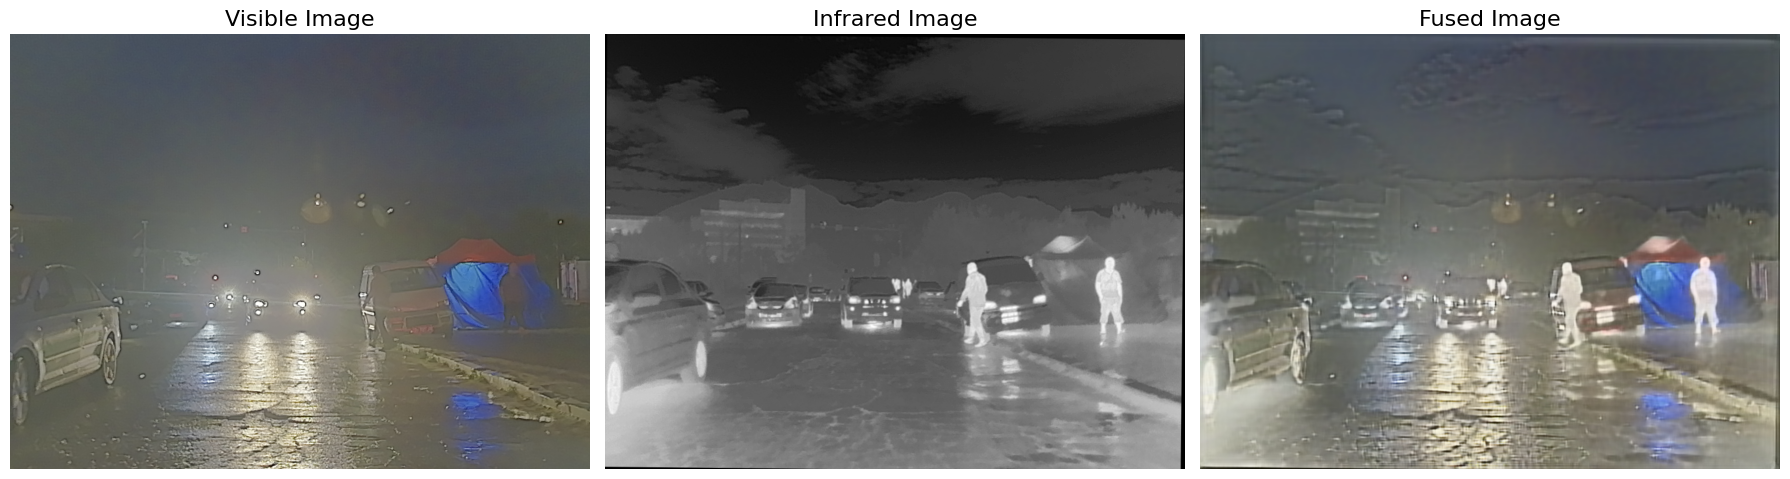

In [9]:
# 4. Visualization
def to_numpy(tensor):
    return (KU.tensor_to_image(tensor.squeeze(0).cpu()) * 255.0).clip(0, 255).astype('uint8')

vis_img = to_numpy(vis_ts)
ir_img = to_numpy(ir_ts)
fused_img = to_numpy(fused_RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(vis_img)
axes[0].set_title('Visible Image', fontsize=16)
axes[0].axis('off')

# Display IR as grayscale (using the first channel since they are usually identical across RGB)
axes[1].imshow(ir_img[:,:,0], cmap='gray')
axes[1].set_title('Infrared Image', fontsize=16)
axes[1].axis('off')

axes[2].imshow(fused_img)
axes[2].set_title('Fused Image', fontsize=16)
axes[2].axis('off')

plt.tight_layout()
plt.show()


# 指标